# Nested Monte Carlo Simulation vs Optimiser-Trained MLP Surrogates: Can Surrogate Modelling Reduce the Computational Cost of Interest-Rate Risk Estimation?

This study investigates whether an MLP surrogate can approximate nested Monte Carlo valuations for interest-rate risk measurement at substantially lower computational cost, while retaining sufficient predictive and risk-measure accuracy. The study further evaluates how the adaptive optimisers Adam, Adagrad and Shampoo affect the training and resulting performance of the MLP surrogate, and examines the sensitivity of these results to the number of inner simulations used to generate the NMC training labels.

## Imports and Data Extraction

In [1]:
# Imports

# Core Libraries
import importlib
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import re

pd.set_option("display.expand_frame_repr", False)


# PyTorch
import torch
import torch.optim as torch_optim

# Shampoo Optimiser
import torch_optimizer as optim


# Reload Updated Modules
import caplet_pricing
import v0_pricing
import nmc_simulation
import nmc_cache
import nmc_sensitivity
import surrogate_model
import bootstrap_analysis
import cloudie

importlib.reload(caplet_pricing)
importlib.reload(v0_pricing)
importlib.reload(nmc_simulation)
importlib.reload(nmc_cache)
importlib.reload(nmc_sensitivity)
importlib.reload(surrogate_model)
importlib.reload(bootstrap_analysis)
importlib.reload(cloudie)

# Caplet Structure
from caplet_pricing import (
    remaining_caplet_boundaries,
    full_caplet_boundaries,
    compound_sonia_business_days,
    calculate_caplet_cashflow,
    calculate_discount_factor
)

# Market Data and Model Parameters
from market_data import (
    r0,
    a,
    sigma,
    strike,
    notional,
    valuation_date,
    risk_date,
    curve,
    curve_t,
    forward_curve,
    number_of_outer_paths,
    number_of_inner_paths,
    risk_horizon_days,
    business_days_per_year
)


# Hull-White Simulation
from hull_white import (
    outer_paths,
    day_10_rates,
    outer_t,
    inner_t,
    inner_forward,
    simulate_inner_hull_white
)


# Initial Cap Pricing
from v0_pricing import calculate_v0


# Nested Monte Carlo
from nmc_cache import load_or_run_nmc

from nmc_simulation import value_cap_at_day_10


# Surrogate Model
from surrogate_model import (
    CapSurrogate,
    prepare_surrogate_data,
    train_surrogate,
    evaluate_surrogate
)


# Bootstrap Analysis
from bootstrap_analysis import (
    create_accuracy_table,
    bootstrap_var_es,
    plot_accuracy_ci,
    calculate_var_es
)


# NMC Sensitivity Analysis
from nmc_sensitivity import load_or_run_allocation


# Cloudie Optimiser Framework
from cloudie import (
    calculate_cloudie_rank,
    calculate_risk_deviation,
    create_cloudie_summary
)

# Plot Colours
optimiser_colours = {
    "Adam": "crimson",
    "Adagrad": "seagreen",
    "Shampoo": "mediumpurple"
}

nmc_colour = "cornflowerblue"

# Data Extraction
print("Valuation date:", valuation_date.date())
print("Risk date:", risk_date.date())

print(f"Initial short rate: {r0:.4%}")
print(f"Hull-White mean reversion: {a:.2%}")
print(f"Hull-White volatility: {sigma:.2%}")

print(f"Notional: £{notional:,.0f}")
print(f"Strike: {strike:.2%}")

print(f"Outer paths: {number_of_outer_paths:,}")
print(f"Inner paths per outer scenario: {number_of_inner_paths:,}")

Valuation date: 2026-08-03
Risk date: 2026-08-17
Initial short rate: 3.7232%
Hull-White mean reversion: 4.00%
Hull-White volatility: 1.00%
Notional: £1,000,000
Strike: 4.00%
Outer paths: 100,000
Inner paths per outer scenario: 1,000


In [2]:
# ============================================================
# File Paths
# ============================================================

sensitivity_dir = "nmc_sensitivity_all"

os.makedirs(
    sensitivity_dir,
    exist_ok=True
)

## Initial Cap value (v0)

In [3]:
V0, caplet_prices, v0_pathwise_values = (
    calculate_v0()
)

for i, price in enumerate(
    caplet_prices,
    start=1
):
    print(
        f"Caplet {i}: £{price:,.2f}"
    )

print(
    f"\nInitial Cap Value V0: "
    f"£{V0:,.2f}"
)

Caplet 1: £90.15
Caplet 2: £534.11
Caplet 3: £982.30
Caplet 4: £1,171.87

Initial Cap Value V0: £2,778.43


# 1. Nested Monte Carlo

## Running Nested Monte Carlo Simulation

In [4]:
nmc_results, nmc_runtime = (
    load_or_run_nmc()
)

print(
    f"NMC scenarios: "
    f"{len(nmc_results):,}"
)

print(
    f"Nested Monte Carlo runtime: "
    f"{nmc_runtime:.2f} seconds"
)

print(
    nmc_results.head(10)
)

Configuration: 100,000 outer × 1,000 inner
Existing NMC results found.
Skipping Nested Monte Carlo simulation.
Configuration: 100,000 outer × 1,000 inner
Loaded 100,000 saved NMC scenarios.
NMC scenarios: 100,000
Nested Monte Carlo runtime: 1828.14 seconds
   Outer Scenario  Day 10 Short Rate  Day 10 Short Rate (%)  Day 10 Cap Value (£)
0               1           0.039829               3.982880           3837.346124
1               2           0.036413               3.641282           2213.339672
2               3           0.038111               3.811067           2950.237398
3               4           0.039856               3.985640           4057.434719
4               5           0.039827               3.982692           3853.883667
5               6           0.036004               3.600425           2180.740369
6               7           0.039331               3.933129           3915.984025
7               8           0.037381               3.738095           2729.333109
8    

## Nested Monte Carlo Loss Distribution

Mean NMC loss: £-14.62
Minimum NMC loss: £-5,579.87
Maximum NMC loss: £2,331.80


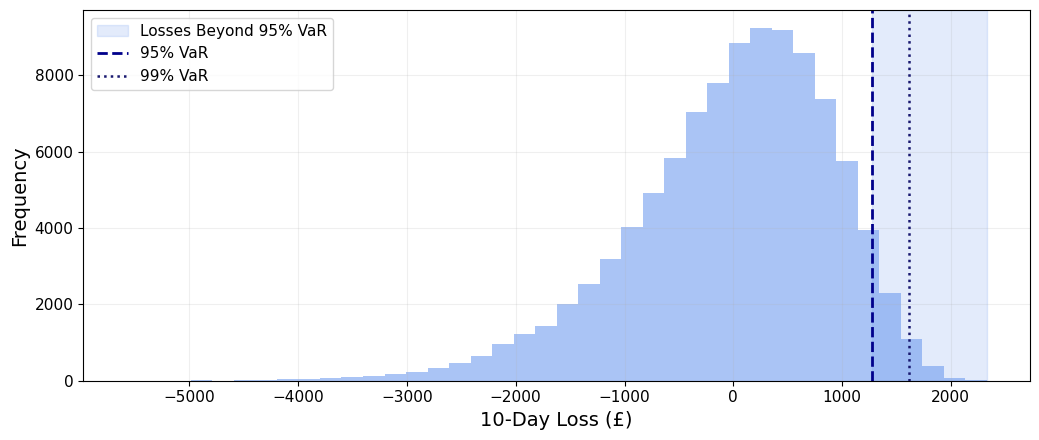

In [77]:
# ============================================================
# NMC 10-Day Loss Distribution
# ============================================================

nmc_cap_values = nmc_results[
    "Day 10 Cap Value (£)"
].to_numpy()

nmc_losses = (
    V0 - nmc_cap_values
)


# ============================================================
# Risk Measures
# ============================================================

nmc_var_95, nmc_es_95 = calculate_var_es(
    nmc_losses,
    0.95
)

nmc_var_99, nmc_es_99 = calculate_var_es(
    nmc_losses,
    0.99
)


print(
    f"Mean NMC loss: "
    f"£{nmc_losses.mean():,.2f}"
)

print(
    f"Minimum NMC loss: "
    f"£{nmc_losses.min():,.2f}"
)

print(
    f"Maximum NMC loss: "
    f"£{nmc_losses.max():,.2f}"
)


# ============================================================
# Histogram
# ============================================================

plt.figure(
    figsize=(10.5, 4.5)
)

plt.hist(
    nmc_losses,
    bins=40,
    color="cornflowerblue",
    alpha=0.55
)


# ============================================================
# Shade Losses Beyond 95% VaR
# ============================================================

plt.axvspan(
    nmc_var_95,
    nmc_losses.max(),
    color="cornflowerblue",
    alpha=0.18,
    label="Losses Beyond 95% VaR"
)


# ============================================================
# VaR Thresholds
# ============================================================

plt.axvline(
    nmc_var_95,
    color="darkblue",
    linestyle="--",
    linewidth=2.0,
    label="95% VaR"
)

plt.axvline(
    nmc_var_99,
    color="midnightblue",
    linestyle=":",
    linewidth=1.8,
    label="99% VaR"
)


# ============================================================
# Plot Formatting
# ============================================================

plt.xlabel(
    "10-Day Loss (£)",
    fontsize=14
)

plt.ylabel(
    "Frequency",
    fontsize=14
)

plt.xticks(
    fontsize=11
)

plt.yticks(
    fontsize=11
)

plt.legend(
    fontsize=11
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "figures/lossdistribution.pdf",
    bbox_inches="tight"
)

plt.show()

# 2. Surrogate Model

### Training the surrogate model

Adam and Adagrad were implemented using the standard learning rates associated with their PyTorch implementations, while Shampoo used a learning rate of 0.01 following the implementation example provided by the torch-optimizer documentation.

In [6]:
# Prepare Benchmark Surrogate Data

(
    benchmark_X_train,
    benchmark_X_test,
    benchmark_y_train,
    benchmark_scaler_X,
    benchmark_scaler_y,
    benchmark_X_test_original,
    benchmark_y_test
) = prepare_surrogate_data(
    nmc_results,
    test_size=0.20,
    seed=42
)

print(
    f"Training observations: "
    f"{benchmark_X_train.shape[0]:,}"
)

print(
    f"Testing observations: "
    f"{benchmark_X_test.shape[0]:,}"
)

Training observations: 80,000
Testing observations: 20,000


### MLP + Adam Optimiser

In [7]:
# MLP + Adam

torch.manual_seed(42)

model_adam = CapSurrogate()

optimiser_adam = torch_optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

model_adam, losses_adam = train_surrogate(
    model=model_adam,
    optimiser=optimiser_adam,
    X_train=benchmark_X_train,
    y_train=benchmark_y_train,
    epochs=1000
)


# Evaluate Adam

predictions_adam, metrics_adam = evaluate_surrogate(
    model=model_adam,
    X_test=benchmark_X_test,
    y_test_original=benchmark_y_test,
    scaler_y=benchmark_scaler_y
)

print("Adam Results")
print(f"MAE:  £{metrics_adam['MAE']:,.2f}")
print(f"RMSE: £{metrics_adam['RMSE']:,.2f}")
print(f"R²:   {metrics_adam['R2']:.4f}")


# Store Adam Results

adam_results = {
    "Optimiser": "Adam",
    "MAE": metrics_adam["MAE"],
    "RMSE": metrics_adam["RMSE"],
    "R2": metrics_adam["R2"],
    "Final Training Loss": losses_adam[-1]
}

Adam Results
MAE:  £81.20
RMSE: £103.17
R²:   0.9877


### MLP + Adagrad Optimiser

In [8]:
# MLP + Adagrad

torch.manual_seed(42)

model_adagrad = CapSurrogate()

optimiser_adagrad = torch_optim.Adagrad(
    model_adagrad.parameters(),
    lr=0.01
)

model_adagrad, losses_adagrad = train_surrogate(
    model=model_adagrad,
    optimiser=optimiser_adagrad,
    X_train=benchmark_X_train,
    y_train=benchmark_y_train,
    epochs=1000
)


# Evaluate Adagrad

predictions_adagrad, metrics_adagrad = evaluate_surrogate(
    model=model_adagrad,
    X_test=benchmark_X_test,
    y_test_original=benchmark_y_test,
    scaler_y=benchmark_scaler_y
)

print("Adagrad Results")
print(f"MAE:  £{metrics_adagrad['MAE']:,.2f}")
print(f"RMSE: £{metrics_adagrad['RMSE']:,.2f}")
print(f"R²:   {metrics_adagrad['R2']:.4f}")


# Store Adagrad Results

adagrad_results = {
    "Optimiser": "Adagrad",
    "MAE": metrics_adagrad["MAE"],
    "RMSE": metrics_adagrad["RMSE"],
    "R2": metrics_adagrad["R2"],
    "Final Training Loss": losses_adagrad[-1]
}

Adagrad Results
MAE:  £81.03
RMSE: £102.86
R²:   0.9878


### MLP + Shampoo Optimiser

In [9]:
# MLP + Shampoo

torch.manual_seed(42)

model_shampoo = CapSurrogate()

optimiser_shampoo = optim.Shampoo(
    model_shampoo.parameters(),
    lr=0.01
)

model_shampoo, losses_shampoo = train_surrogate(
    model=model_shampoo,
    optimiser=optimiser_shampoo,
    X_train=benchmark_X_train,
    y_train=benchmark_y_train,
    epochs=1000
)


# Evaluate Shampoo

predictions_shampoo, metrics_shampoo = evaluate_surrogate(
    model=model_shampoo,
    X_test=benchmark_X_test,
    y_test_original=benchmark_y_test,
    scaler_y=benchmark_scaler_y
)

print("Shampoo Results")
print(f"MAE:  £{metrics_shampoo['MAE']:,.2f}")
print(f"RMSE: £{metrics_shampoo['RMSE']:,.2f}")
print(f"R²:   {metrics_shampoo['R2']:.4f}")


# Store Shampoo Results

shampoo_results = {
    "Optimiser": "Shampoo",
    "MAE": metrics_shampoo["MAE"],
    "RMSE": metrics_shampoo["RMSE"],
    "R2": metrics_shampoo["R2"],
    "Final Training Loss": losses_shampoo[-1]
}

Shampoo Results
MAE:  £84.22
RMSE: £110.45
R²:   0.9860


## Evaluating Surrogate Model

### Predictive Accuracy

In [12]:
optimiser_predictions = {
    "Adam": predictions_adam,
    "Adagrad": predictions_adagrad,
    "Shampoo": predictions_shampoo
}

optimiser_results = create_accuracy_table(
    y_true=benchmark_y_test,
    predictions=optimiser_predictions
)

display_columns = [
    "Optimiser",
    "MAE",
    "RMSE",
    "R2",
    "MAE 95% CI",
    "RMSE 95% CI",
    "R2 95% CI"
]

optimiser_results[
    display_columns
]

,Optimiser,MAE,RMSE,R2,MAE 95% CI,RMSE 95% CI,R2 95% CI
0,Adam,81.20,103.17,0.9877,"[80.29, 82.06]","[101.99, 104.23]","[0.9874, 0.9881]"
1,Adagrad,81.03,102.86,0.9878,"[80.12, 81.89]","[101.69, 103.90]","[0.9875, 0.9882]"
2,Shampoo,84.22,110.45,0.9860,"[83.20, 85.21]","[108.51, 112.47]","[0.9855, 0.9864]"


### Training Performance: Epochs to converge

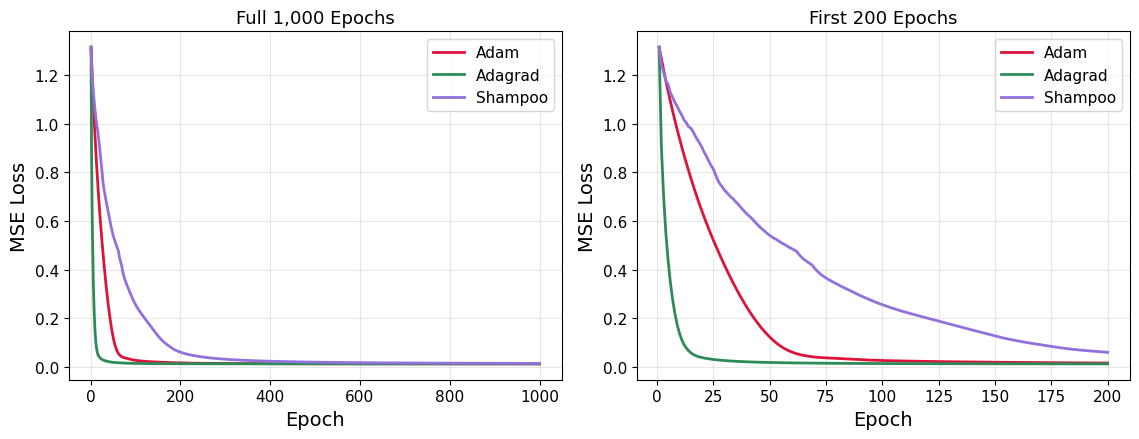

In [55]:
# ============================================================
# Figure Formatting
# ============================================================

axis_label_size = 14
tick_label_size = 11
legend_size = 11
title_size = 13

# ============================================================
# 2. Training Convergence — 1,000 Inner Paths
# ============================================================

epochs = np.arange(
    1,
    len(losses_adam) + 1
)

training_losses = {
    "Adam": losses_adam,
    "Adagrad": losses_adagrad,
    "Shampoo": losses_shampoo
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.5)
)


# ============================================================
# Full 1,000 Epochs
# ============================================================

for optimiser, losses in training_losses.items():

    axes[0].plot(
        epochs,
        losses,
        color=optimiser_colours[optimiser],
        label=optimiser,
        linewidth=2
    )

axes[0].set_xlabel(
    "Epoch",
    fontsize=axis_label_size
)

axes[0].set_ylabel(
    "MSE Loss",
    fontsize=axis_label_size
)

axes[0].set_title(
    "Full 1,000 Epochs",
    fontsize=title_size
)

axes[0].tick_params(
    axis="both",
    labelsize=tick_label_size
)

axes[0].legend(
    fontsize=legend_size
)

axes[0].grid(
    alpha=0.3
)


# ============================================================
# First 200 Epochs
# ============================================================

for optimiser, losses in training_losses.items():

    axes[1].plot(
        epochs[:200],
        losses[:200],
        color=optimiser_colours[optimiser],
        label=optimiser,
        linewidth=2
    )

axes[1].set_xlabel(
    "Epoch",
    fontsize=axis_label_size
)

axes[1].set_ylabel(
    "MSE Loss",
    fontsize=axis_label_size
)

axes[1].set_title(
    "First 200 Epochs",
    fontsize=title_size
)

axes[1].tick_params(
    axis="both",
    labelsize=tick_label_size
)

axes[1].legend(
    fontsize=legend_size
)

axes[1].grid(
    alpha=0.3
)


# ============================================================
# Save Figure
# ============================================================

plt.tight_layout()

plt.savefig(
    "figures/training_loss_1000.pdf",
    bbox_inches="tight"
)

plt.show()

In [14]:
#Final Training Loss

print(f"Adam final loss:     {losses_adam[-1]:.6f}")
print(f"Adagrad final loss:  {losses_adagrad[-1]:.6f}")
print(f"Shampoo final loss:  {losses_shampoo[-1]:.6f}")

Adam final loss:     0.012307
Adagrad final loss:  0.012212
Shampoo final loss:  0.014060


A lower final training loss means the optimiser ended training with a better fit to the training targets.

### Surrogate run time

                SAME DAY-10 OUTER STATES
                         │
              ┌──────────┴──────────┐
              ↓                     ↓
             NMC                   MLP
              ↓                     ↓
       1,000 inner paths       Direct prediction
              ↓                     ↓
       SONIA compounding            │
              ↓                     │
        Caplet payoffs              │
              ↓                     │
          Discounting               │
              ↓                     │
           Average                  │
              ↓                     ↓
             V₁₀            Predicted V₁₀
              │                     │
              └──────────┬──────────┘
                         ↓
                    Compare
              accuracy + runtime

In [15]:
# ============================================================
# Surrogate Inference Runtime
# ============================================================

surrogate_X = nmc_results[
    ["Day 10 Short Rate"]
].to_numpy(dtype=np.float32)

surrogate_X_scaled = (
    benchmark_scaler_X.transform(
        surrogate_X
    )
)

surrogate_X_tensor = torch.tensor(
    surrogate_X_scaled,
    dtype=torch.float32
)


# ============================================================
# 1. Benchmark surrogate inference
# ============================================================

def benchmark_surrogate_inference(
    model,
    X,
    scaler_y,
    n_repeats=100,
    n_warmup=5
):

    model.eval()


    # --------------------------------------------------------
    # Warm-up runs
    # --------------------------------------------------------

    with torch.no_grad():

        for _ in range(n_warmup):

            predictions_scaled = (
                model(X).numpy()
            )

            scaler_y.inverse_transform(
                predictions_scaled
            )


    # --------------------------------------------------------
    # Timed runs
    # --------------------------------------------------------

    runtimes = []

    with torch.no_grad():

        for _ in range(n_repeats):

            start_time = time.perf_counter()

            predictions_scaled = (
                model(X).numpy()
            )

            predictions = (
                scaler_y
                .inverse_transform(
                    predictions_scaled
                )
                .flatten()
            )

            runtimes.append(
                time.perf_counter()
                - start_time
            )

    return (
        predictions,
        np.array(runtimes)
    )


# ============================================================
# 2. Run inference benchmark
# ============================================================

adam_v10, adam_times = benchmark_surrogate_inference(
    model_adam,
    surrogate_X_tensor,
    benchmark_scaler_y
)

adagrad_v10, adagrad_times = benchmark_surrogate_inference(
    model_adagrad,
    surrogate_X_tensor,
    benchmark_scaler_y
)

shampoo_v10, shampoo_times = benchmark_surrogate_inference(
    model_shampoo,
    surrogate_X_tensor,
    benchmark_scaler_y
)


# ============================================================
# 3. Inference runtime results
# ============================================================

runtime_results = pd.DataFrame({
    "Method": [
        "NMC",
        "Adam",
        "Adagrad",
        "Shampoo"
    ],

    "Mean Runtime (s)": [
        nmc_runtime,
        np.mean(adam_times),
        np.mean(adagrad_times),
        np.mean(shampoo_times)
    ],

    "Std Runtime (s)": [
        np.nan,
        np.std(adam_times),
        np.std(adagrad_times),
        np.std(shampoo_times)
    ]
})

runtime_results["Speed-up vs NMC"] = (
    nmc_runtime
    / runtime_results["Mean Runtime (s)"]
)

runtime_results.loc[
    runtime_results["Method"] == "NMC",
    "Speed-up vs NMC"
] = np.nan


# ============================================================
# 4. Display results
# ============================================================

runtime_display = runtime_results[
    [
        "Method",
        "Mean Runtime (s)",
        "Std Runtime (s)",
        "Speed-up vs NMC"
    ]
].copy()

runtime_display.style.format({
    "Mean Runtime (s)": "{:.6f}",
    "Std Runtime (s)": "{:.6f}",
    "Speed-up vs NMC": "{:,.0f}×"
}, na_rep="—")

,Method,Mean Runtime (s),Std Runtime (s),Speed-up vs NMC
0,NMC,1828.140956,—,—
1,Adam,0.043954,0.003437,"41,592×"
2,Adagrad,0.044199,0.005403,"41,361×"
3,Shampoo,0.042749,0.006929,"42,764×"


### Risk Measures: VAR and ES comparison

In [17]:
# ============================================================
# Bootstrap Risk Measures for 1,000-Inner Baseline
# ============================================================

bootstrap_file_1000 = os.path.join(
    sensitivity_dir,
    "bootstrap_risk_1000.csv"
)


# ============================================================
# Load Existing Results
# ============================================================

if os.path.exists(
    bootstrap_file_1000
):

    print(
        "Existing 1,000-inner "
        "bootstrap results found."
    )

    print(
        "Skipping bootstrap calculation."
    )

    bootstrap_risk_1000 = pd.read_csv(
        bootstrap_file_1000
    )


# ============================================================
# Otherwise Run Bootstrap
# ============================================================

else:

    # --------------------------------------------------------
    # Construct 1,000-inner loss distributions
    # --------------------------------------------------------

    nmc_cap_values_1000 = nmc_results[
        "Day 10 Cap Value (£)"
    ].to_numpy()

    losses_1000 = {
        "Nested Monte Carlo":
            V0 - nmc_cap_values_1000,

        "MLP + Adam":
            V0 - adam_v10,

        "MLP + Adagrad":
            V0 - adagrad_v10,

        "MLP + Shampoo":
            V0 - shampoo_v10
    }


    bootstrap_rows_1000 = []


    # --------------------------------------------------------
    # Bootstrap each method
    # --------------------------------------------------------

    for method, losses in (
        losses_1000.items()
    ):

        print(
            f"Bootstrapping {method} "
            "with 1,000 inner paths..."
        )


        # ----------------------------------------------------
        # 95% VaR and ES
        # ----------------------------------------------------

        var_95, es_95 = calculate_var_es(
            losses,
            0.95
        )

        ci_95 = bootstrap_var_es(
            losses=losses,
            confidence_level=0.95,
            n_resamples=1000,
            bootstrap_confidence_level=0.95,
            seed=42
        )


        # ----------------------------------------------------
        # 99% VaR and ES
        # ----------------------------------------------------

        var_99, es_99 = calculate_var_es(
            losses,
            0.99
        )

        ci_99 = bootstrap_var_es(
            losses=losses,
            confidence_level=0.99,
            n_resamples=1000,
            bootstrap_confidence_level=0.95,
            seed=42
        )


        # ----------------------------------------------------
        # Store Results
        # ----------------------------------------------------

        bootstrap_rows_1000.append({

            "Inner Paths": 1000,

            "Method": method,

            "95% VaR (£)": var_95,

            "95% VaR 95% CI":
                f"[£{ci_95['VaR Lower']:,.2f}, "
                f"£{ci_95['VaR Upper']:,.2f}]",

            "95% ES (£)": es_95,

            "95% ES 95% CI":
                f"[£{ci_95['ES Lower']:,.2f}, "
                f"£{ci_95['ES Upper']:,.2f}]",

            "99% VaR (£)": var_99,

            "99% VaR 95% CI":
                f"[£{ci_99['VaR Lower']:,.2f}, "
                f"£{ci_99['VaR Upper']:,.2f}]",

            "99% ES (£)": es_99,

            "99% ES 95% CI":
                f"[£{ci_99['ES Lower']:,.2f}, "
                f"£{ci_99['ES Upper']:,.2f}]"
        })


    # ========================================================
    # Create and Save Results
    # ========================================================

    bootstrap_risk_1000 = pd.DataFrame(
        bootstrap_rows_1000
    )

    bootstrap_risk_1000.to_csv(
        bootstrap_file_1000,
        index=False
    )

    print(
        "1,000-inner bootstrap "
        "results saved successfully."
    )


# ============================================================
# Display Results
# ============================================================
risk_results = bootstrap_risk_1000.copy()
bootstrap_risk_1000

Bootstrapping Nested Monte Carlo with 1,000 inner paths...
Bootstrapping MLP + Adam with 1,000 inner paths...
Bootstrapping MLP + Adagrad with 1,000 inner paths...
Bootstrapping MLP + Shampoo with 1,000 inner paths...
1,000-inner bootstrap results saved successfully.


,Inner Paths,Method,95% VaR (£),95% VaR 95% CI,95% ES (£),95% ES 95% CI,99% VaR (£),99% VaR 95% CI,99% ES (£),99% ES 95% CI
0,1000,Nested Monte Carlo,1272.377181,"[£1,264.88, £1,280.03]",1483.352536,"[£1,475.84, £1,490.40]",1613.477300,"[£1,604.02, £1,624.12]",1754.565629,"[£1,742.88, £1,765.89]"
1,1000,MLP + Adam,1260.839208,"[£1,254.04, £1,268.26]",1470.147809,"[£1,462.80, £1,477.51]",1593.607536,"[£1,584.39, £1,602.31]",1744.426051,"[£1,731.18, £1,758.05]"
2,1000,MLP + Adagrad,1261.842114,"[£1,254.88, £1,269.44]",1471.371257,"[£1,464.03, £1,478.68]",1593.898404,"[£1,584.87, £1,602.43]",1741.884970,"[£1,728.90, £1,755.29]"
3,1000,MLP + Shampoo,1257.081390,"[£1,249.91, £1,264.90]",1470.071747,"[£1,462.82, £1,477.20]",1605.168043,"[£1,595.38, £1,614.41]",1736.512398,"[£1,726.16, £1,746.83]"


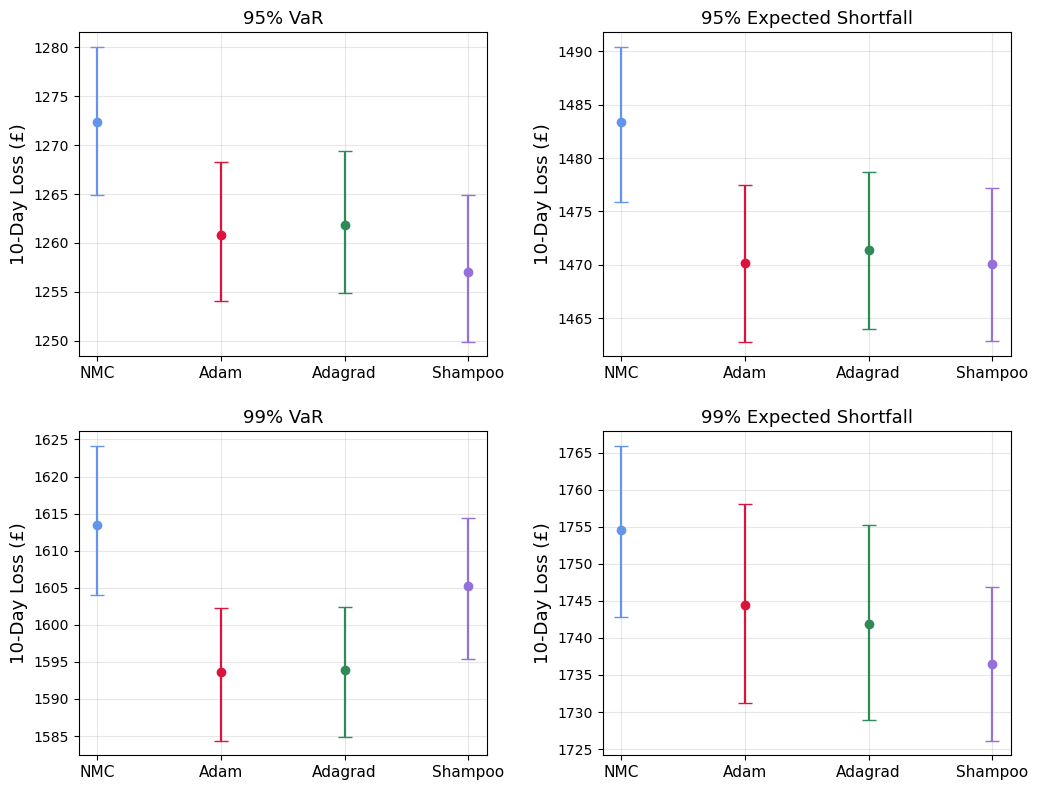

In [72]:
# ============================================================
# Benchmark Risk Estimates with Bootstrap Confidence Intervals
# ============================================================

risk_results = bootstrap_risk_1000.copy()


# ============================================================
# Parse Bootstrap Confidence Intervals
# ============================================================

def parse_ci(ci_string):

    numbers = re.findall(
        r"£([\d,]+\.\d+)",
        ci_string
    )

    lower = float(
        numbers[0].replace(",", "")
    )

    upper = float(
        numbers[1].replace(",", "")
    )

    return lower, upper


# ============================================================
# Plot Colours
# ============================================================

method_colours = {
    "Nested Monte Carlo": nmc_colour,
    "MLP + Adam": optimiser_colours["Adam"],
    "MLP + Adagrad": optimiser_colours["Adagrad"],
    "MLP + Shampoo": optimiser_colours["Shampoo"]
}

method_labels = {
    "Nested Monte Carlo": "NMC",
    "MLP + Adam": "Adam",
    "MLP + Adagrad": "Adagrad",
    "MLP + Shampoo": "Shampoo"
}


# ============================================================
# Risk Measure Plots
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.5, 8)
)

plots = [
    (
        "95% VaR (£)",
        "95% VaR 95% CI",
        "95% VaR"
    ),
    (
        "95% ES (£)",
        "95% ES 95% CI",
        "95% Expected Shortfall"
    ),
    (
        "99% VaR (£)",
        "99% VaR 95% CI",
        "99% VaR"
    ),
    (
        "99% ES (£)",
        "99% ES 95% CI",
        "99% Expected Shortfall"
    )
]


for ax, (
    value_column,
    ci_column,
    title
) in zip(
    axes.flatten(),
    plots
):

    values = risk_results[
        value_column
    ].to_numpy()


    # ========================================================
    # Extract CI Bounds
    # ========================================================

    ci_bounds = [
        parse_ci(ci)
        for ci in risk_results[
            ci_column
        ]
    ]

    lower = np.array([
        bounds[0]
        for bounds in ci_bounds
    ])

    upper = np.array([
        bounds[1]
        for bounds in ci_bounds
    ])


    # ========================================================
    # Plot Estimates and Confidence Intervals
    # ========================================================

    for i, method in enumerate(
        risk_results["Method"]
    ):

        ax.errorbar(
            i,
            values[i],
            yerr=[[
                values[i] - lower[i]
            ], [
                upper[i] - values[i]
            ]],
            fmt="o",
            markersize=6,
            capsize=5,
            linewidth=1.6,
            color=method_colours[method]
        )


    # ========================================================
    # Plot Formatting
    # ========================================================

    ax.set_xticks(
        range(len(risk_results))
    )

    ax.set_xticklabels(
        [
            method_labels[method]
            for method in risk_results["Method"]
        ],
        fontsize=11
    )

    ax.set_ylabel(
        "10-Day Loss (£)",
        fontsize=13
    )

    ax.set_title(
        title,
        fontsize=13
    )

    ax.tick_params(
        axis="y",
        labelsize=10
    )

    ax.grid(
        alpha=0.3
    )


plt.tight_layout(
    h_pad=2.0,
    w_pad=2.0
)

plt.savefig(
    "figures/risk_estimates_bootstrap_1000.pdf",
    bbox_inches="tight"
)

plt.show()

### Percentage difference from NMC benchmark

In [19]:
# Percentage Difference from NMC Benchmark

comparison = risk_results.copy()

risk_measures = [
    "95% VaR (£)",
    "95% ES (£)",
    "99% VaR (£)",
    "99% ES (£)"
]

nmc_benchmark = comparison[
    comparison["Method"] == "Nested Monte Carlo"
].iloc[0]

for measure in risk_measures:

    comparison[
        measure.replace(
            " (£)",
            " Difference (%)"
        )
    ] = (
        (
            comparison[measure]
            - nmc_benchmark[measure]
        )
        / nmc_benchmark[measure]
        * 100
    )


# Display Percentage Differences

difference_columns = [
    "Method",
    "95% VaR Difference (%)",
    "95% ES Difference (%)",
    "99% VaR Difference (%)",
    "99% ES Difference (%)"
]

comparison[
    difference_columns
].round(2)

,Method,95% VaR Difference (%),95% ES Difference (%),99% VaR Difference (%),99% ES Difference (%)
0,Nested Monte Carlo,0.00,0.00,0.00,0.00
1,MLP + Adam,-0.91,-0.89,-1.23,-0.58
2,MLP + Adagrad,-0.83,-0.81,-1.21,-0.72
3,MLP + Shampoo,-1.20,-0.90,-0.51,-1.03


# 3. Sensitivity to inner simulations

In [20]:
# Sensitivity to Inner Simulations

nmc_500, runtime_500 = load_or_run_allocation(
    500
)

nmc_250, runtime_250 = load_or_run_allocation(
    250
)

nmc_100, runtime_100 = load_or_run_allocation(
    100
)

Existing 500-inner sensitivity results found.
Skipping NMC simulation.
Existing 250-inner sensitivity results found.
Skipping NMC simulation.
Existing 100-inner sensitivity results found.
Skipping NMC simulation.


## Surrogate Data Extractions

In [21]:
# Prepare Sensitivity Datasets

sensitivity_datasets = {
    1000: nmc_results,
    500: nmc_500,
    250: nmc_250,
    100: nmc_100
}

prepared_data = {}

for n_inner, dataset in sensitivity_datasets.items():

    (
        X_train_i,
        X_test_i,
        y_train_i,
        scaler_X_i,
        scaler_y_i,
        X_test_original_i,
        y_test_i
    ) = prepare_surrogate_data(
        dataset,
        test_size=0.20,
        seed=42
    )

    prepared_data[n_inner] = {
        "X_train": X_train_i,
        "X_test": X_test_i,
        "y_train": y_train_i,
        "scaler_X": scaler_X_i,
        "scaler_y": scaler_y_i,
        "X_test_original": X_test_original_i,
        "y_test": y_test_i
    }

    print(
    f"{n_inner:,} inner: "
    f"{len(dataset):,} observations | "
    f"{X_train_i.shape[0]:,} train / "
    f"{X_test_i.shape[0]:,} test"
    )

1,000 inner: 100,000 observations | 80,000 train / 20,000 test
500 inner: 100,000 observations | 80,000 train / 20,000 test
250 inner: 100,000 observations | 80,000 train / 20,000 test
100 inner: 100,000 observations | 80,000 train / 20,000 test


In [22]:
# Train or Load Sensitivity Surrogate Models

sensitivity_models = {}
sensitivity_losses = {}
sensitivity_predictions = {}
sensitivity_metrics = {}

for n_inner in [
    500,
    250,
    100
]:

    data = prepared_data[
        n_inner
    ]

    sensitivity_models[n_inner] = {}
    sensitivity_losses[n_inner] = {}
    sensitivity_predictions[n_inner] = {}
    sensitivity_metrics[n_inner] = {}


    for optimiser_name in [
        "Adam",
        "Adagrad",
        "Shampoo"
    ]:

        model_file = os.path.join(
            sensitivity_dir,
            f"sensitivity_{n_inner}_{optimiser_name}_model.pt"
        )

        losses_file = os.path.join(
            sensitivity_dir,
            f"sensitivity_{n_inner}_{optimiser_name}_losses.npy"
        )


        # Load Existing Model

        if (
            os.path.exists(model_file)
            and os.path.exists(losses_file)
        ):

            print(
                f"Loading {optimiser_name} "
                f"with {n_inner} inner labels..."
            )

            model = CapSurrogate()

            model.load_state_dict(
                torch.load(
                    model_file,
                    weights_only=True
                )
            )

            losses = np.load(
                losses_file
            ).tolist()

            print(
                "Existing model found. "
                "Skipping training."
            )


        # Train New Model

        else:

            print(
                f"Training {optimiser_name} "
                f"with {n_inner} inner labels..."
            )

            torch.manual_seed(42)

            model = CapSurrogate()


            # Select Optimiser

            if optimiser_name == "Adam":

                optimiser = torch_optim.Adam(
                    model.parameters(),
                    lr=0.001
                )

            elif optimiser_name == "Adagrad":

                optimiser = torch_optim.Adagrad(
                    model.parameters(),
                    lr=0.01
                )

            else:

                optimiser = optim.Shampoo(
                    model.parameters(),
                    lr=0.01
                )


            # Train Surrogate

            model, losses = train_surrogate(
                model=model,
                optimiser=optimiser,
                X_train=data["X_train"],
                y_train=data["y_train"],
                epochs=1000
            )


            # Save Model and Training Losses

            torch.save(
                model.state_dict(),
                model_file
            )

            np.save(
                losses_file,
                np.asarray(losses)
            )

            print(
                "Model saved successfully."
            )


        # Evaluate Surrogate

        predictions, metrics = evaluate_surrogate(
            model=model,
            X_test=data["X_test"],
            y_test_original=data["y_test"],
            scaler_y=data["scaler_y"]
        )


        # Store Results

        sensitivity_models[
            n_inner
        ][optimiser_name] = model

        sensitivity_losses[
            n_inner
        ][optimiser_name] = losses

        sensitivity_predictions[
            n_inner
        ][optimiser_name] = (
            predictions.flatten()
        )

        sensitivity_metrics[
            n_inner
        ][optimiser_name] = metrics


        # Display Results

        print(
            f"MAE: £{metrics['MAE']:,.2f}"
        )

        print(
            f"RMSE: £{metrics['RMSE']:,.2f}"
        )

        print(
            f"R²: {metrics['R2']:.4f}"
        )

        print(
            f"Final loss: {losses[-1]:.6f}"
        )

        print()

Loading Adam with 500 inner labels...
Existing model found. Skipping training.
MAE: £115.28
RMSE: £146.08
R²: 0.9757
Final loss: 0.024055

Loading Adagrad with 500 inner labels...
Existing model found. Skipping training.
MAE: £115.18
RMSE: £145.90
R²: 0.9758
Final loss: 0.023967

Loading Shampoo with 500 inner labels...
Existing model found. Skipping training.
MAE: £117.56
RMSE: £150.83
R²: 0.9741
Final loss: 0.025718

Loading Adam with 250 inner labels...
Existing model found. Skipping training.
MAE: £160.76
RMSE: £203.85
R²: 0.9538
Final loss: 0.046647

Loading Adagrad with 250 inner labels...
Existing model found. Skipping training.
MAE: £160.74
RMSE: £203.76
R²: 0.9539
Final loss: 0.046571

Loading Shampoo with 250 inner labels...
Existing model found. Skipping training.
MAE: £161.86
RMSE: £206.42
R²: 0.9527
Final loss: 0.047979

Loading Adam with 100 inner labels...
Existing model found. Skipping training.
MAE: £254.69
RMSE: £323.04
R²: 0.8914
Final loss: 0.108789

Loading Adagrad

In [23]:
# Accuracy Across Inner Allocations

all_metrics = {
    1000: {
        "Adam": metrics_adam,
        "Adagrad": metrics_adagrad,
        "Shampoo": metrics_shampoo
    },
    500: sensitivity_metrics[500],
    250: sensitivity_metrics[250],
    100: sensitivity_metrics[100]
}

rows = []

for n_inner, optimiser_metrics in all_metrics.items():

    for optimiser, metrics in optimiser_metrics.items():

        rows.append({
            "Inner Paths": n_inner,
            "Optimiser": optimiser,
            "MAE (£)": metrics["MAE"],
            "RMSE (£)": metrics["RMSE"],
            "R²": metrics["R2"]
        })

accuracy_sensitivity = pd.DataFrame(rows)


# ============================================================
# RMSE decomposition
# RMSE^2 = A + B / N_inner
# ============================================================

decomposition = {}

for optimiser in [
    "Adam",
    "Adagrad",
    "Shampoo"
]:

    group = accuracy_sensitivity[
        accuracy_sensitivity["Optimiser"] == optimiser
    ]

    x = (
        1
        / group["Inner Paths"].to_numpy()
    )

    y = (
        group["RMSE (£)"].to_numpy()
        ** 2
    )

    B, A = np.polyfit(
        x,
        y,
        1
    )

    decomposition[optimiser] = {
        "A": A,
        "B": B
    }


# Add decomposition columns

accuracy_sensitivity[
    "Surrogate Error Floor (£)"
] = accuracy_sensitivity.apply(
    lambda row:
        np.sqrt(
            decomposition[row["Optimiser"]]["A"]
        ),
    axis=1
)

accuracy_sensitivity[
    "MC Error (£)"
] = accuracy_sensitivity.apply(
    lambda row:
        np.sqrt(
            decomposition[row["Optimiser"]]["B"]
            / row["Inner Paths"]
        ),
    axis=1
)


# Round for display

accuracy_sensitivity[
    [
        "MAE (£)",
        "RMSE (£)",
        "Surrogate Error Floor (£)",
        "MC Error (£)"
    ]
] = accuracy_sensitivity[
    [
        "MAE (£)",
        "RMSE (£)",
        "Surrogate Error Floor (£)",
        "MC Error (£)"
    ]
].round(2)

accuracy_sensitivity[
    "R²"
] = accuracy_sensitivity[
    "R²"
].round(4)

accuracy_sensitivity

,Inner Paths,Optimiser,MAE (£),RMSE (£),R²,Surrogate Error Floor (£),MC Error (£)
0,1000,Adam,81.20,103.17,0.9877,16.39,101.99
1,1000,Adagrad,81.03,102.86,0.9878,14.35,102.01
2,1000,Shampoo,84.22,110.45,0.9860,42.04,101.70
3,500,Adam,115.28,146.08,0.9757,16.39,144.23
4,500,Adagrad,115.18,145.90,0.9758,14.35,144.26
5,500,Shampoo,117.56,150.83,0.9741,42.04,143.82
6,250,Adam,160.76,203.85,0.9538,16.39,203.97
7,250,Adagrad,160.74,203.76,0.9539,14.35,204.02
8,250,Shampoo,161.86,206.42,0.9527,42.04,203.40
9,100,Adam,254.69,323.04,0.8914,16.39,322.51


## Convergence

In [24]:
# Convergence Across Inner Allocations

def convergence_epoch(
    losses,
    proportion=0.99
):

    losses = np.asarray(
        losses
    )

    initial_loss = losses[0]
    final_loss = losses[-1]

    target_loss = (
        initial_loss
        - proportion
        * (initial_loss - final_loss)
    )

    return (
        np.where(
            losses <= target_loss
        )[0][0]
        + 1
    )


# Training Losses by Inner Allocation

losses_by_allocation = {
    1000: {
        "Adam": losses_adam,
        "Adagrad": losses_adagrad,
        "Shampoo": losses_shampoo
    },
    500: sensitivity_losses[500],
    250: sensitivity_losses[250],
    100: sensitivity_losses[100]
}


# Calculate Convergence Epochs

rows = []

for n_inner, optimiser_losses in losses_by_allocation.items():

    for optimiser, losses in optimiser_losses.items():

        rows.append({
            "Inner Paths": n_inner,
            "Optimiser": optimiser,
            "Convergence Epoch":
                convergence_epoch(losses),
            "Final Loss":
                losses[-1]
        })

convergence_results = pd.DataFrame(
    rows
)

convergence_results.style.format({
    "Final Loss": "{:.6f}"
})

,Inner Paths,Optimiser,Convergence Epoch,Final Loss
0,1000,Adam,107,0.012307
1,1000,Adagrad,32,0.012212
2,1000,Shampoo,341,0.014060
3,500,Adam,106,0.024055
4,500,Adagrad,32,0.023967
5,500,Shampoo,336,0.025718
6,250,Adam,107,0.046647
7,250,Adagrad,32,0.046571
8,250,Shampoo,374,0.047979
9,100,Adam,105,0.108789


In [56]:
# ============================================================
# Plot Optimiser Convergence by Inner Allocation
# ============================================================

def plot_convergence(
    n_inner
):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 4.5)
    )

    allocation_losses = (
        losses_by_allocation[n_inner]
    )


    # ========================================================
    # Full 1,000 Epochs
    # ========================================================

    for optimiser, losses in (
        allocation_losses.items()
    ):

        epochs = np.arange(
            1,
            len(losses) + 1
        )

        axes[0].plot(
            epochs,
            losses,
            color=optimiser_colours[
                optimiser
            ],
            label=optimiser,
            linewidth=1.6
        )

    axes[0].set_xlabel(
        "Epoch",
        fontsize=14
    )

    axes[0].set_ylabel(
        "MSE Loss",
        fontsize=14
    )

    axes[0].set_title(
        "Full 1,000 Epochs",
        fontsize=13
    )

    axes[0].tick_params(
        axis="both",
        labelsize=11
    )

    axes[0].legend(
        fontsize=11
    )

    axes[0].grid(
        alpha=0.3
    )


    # ========================================================
    # First 200 Epochs
    # ========================================================

    for optimiser, losses in (
        allocation_losses.items()
    ):

        epochs = np.arange(
            1,
            len(losses) + 1
        )

        axes[1].plot(
            epochs[:200],
            losses[:200],
            color=optimiser_colours[
                optimiser
            ],
            label=optimiser,
            linewidth=1.6
        )

    axes[1].set_xlabel(
        "Epoch",
        fontsize=14
    )

    axes[1].set_ylabel(
        "MSE Loss",
        fontsize=14
    )

    axes[1].set_title(
        "First 200 Epochs",
        fontsize=13
    )

    axes[1].tick_params(
        axis="both",
        labelsize=11
    )

    axes[1].legend(
        fontsize=11
    )

    axes[1].grid(
        alpha=0.3
    )


    # ========================================================
    # Save
    # ========================================================

    plt.tight_layout()

    plt.savefig(
        f"figures/training_loss_{n_inner}.pdf",
        bbox_inches="tight"
    )

    plt.show()

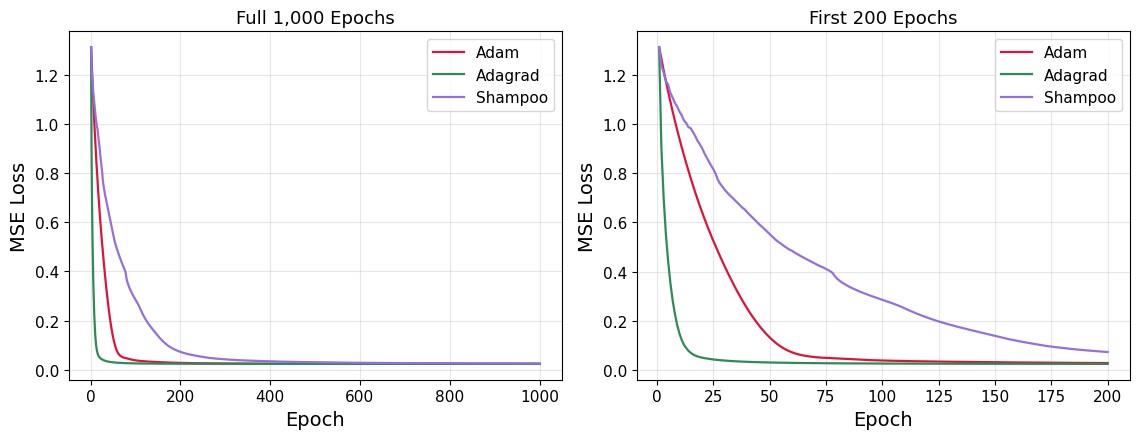

In [57]:
plot_convergence(
    500
)

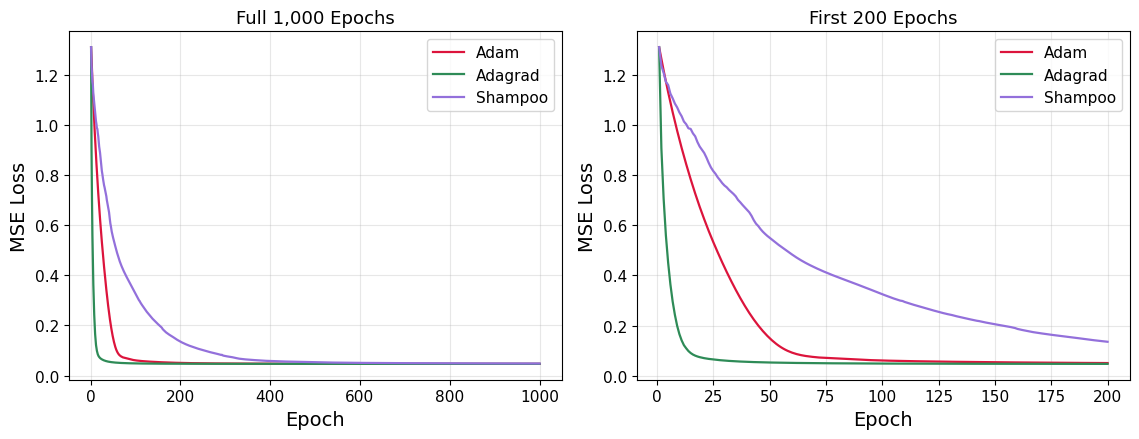

In [58]:
plot_convergence(
    250
)

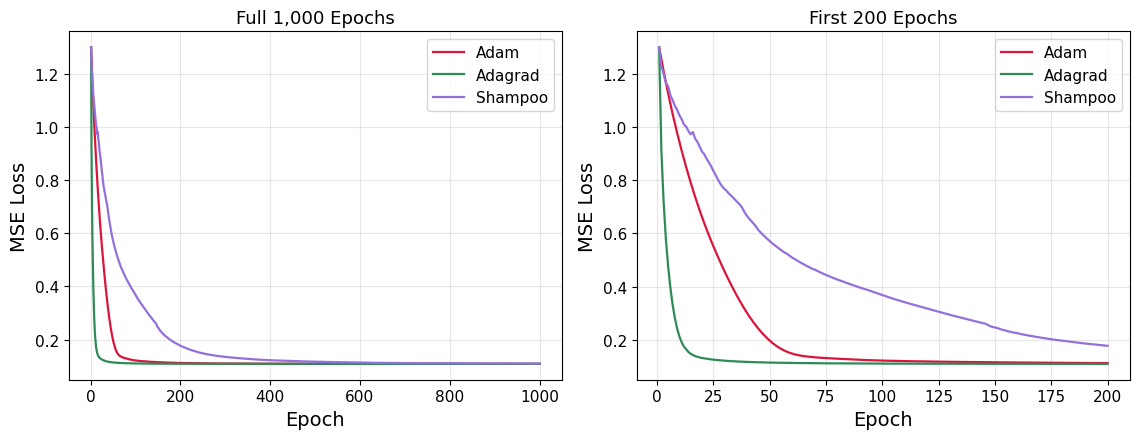

In [59]:
plot_convergence(
    100
)

## Inference Time

In [26]:
# Inference Time to Generate V10

inference_rows = []

n_repeats = 100
n_warmup = 5

for n_inner in [
    1000,
    500,
    250,
    100
]:

    data = sensitivity_datasets[
        n_inner
    ]

    rates = (
        data["Day 10 Short Rate"]
        .to_numpy(dtype=np.float32)
        .reshape(-1, 1)
    )

    current_scaler_X = prepared_data[
        n_inner
    ]["scaler_X"]
    
    current_scaler_y = prepared_data[
        n_inner
    ]["scaler_y"]

    X_tensor = torch.tensor(
    current_scaler_X.transform(
        rates
    ),
    dtype=torch.float32
    )


    # Select Models

    if n_inner == 1000:

        models = {
            "Adam": model_adam,
            "Adagrad": model_adagrad,
            "Shampoo": model_shampoo
        }

    else:

        models = sensitivity_models[
            n_inner
        ]


    # Benchmark Inference

    for optimiser, model in models.items():

        model.eval()

        times = []

        with torch.no_grad():

            # Warm-up Runs
            for _ in range(n_warmup):

                predictions_scaled = (
                    model(X_tensor).numpy()
                )

                current_scaler_y.inverse_transform(
                      predictions_scaled
               )


            # Timed Runs
            for _ in range(n_repeats):

                start_time = time.perf_counter()

                predictions_scaled = (
                    model(X_tensor).numpy()
                )

                current_scaler_y.inverse_transform(
                    predictions_scaled
                )

                times.append(
                    time.perf_counter()
                    - start_time
                )

        times = np.asarray(
            times
        )

        inference_rows.append({
            "Inner Paths": n_inner,
            "Optimiser": optimiser,
            "Mean Inference Time (ms)":
                times.mean() * 1000,
            "Runtime SD (ms)":
                times.std(ddof=1) * 1000
        })


inference_results = pd.DataFrame(
    inference_rows
)

inference_results.style.format({
    "Mean Inference Time (ms)": "{:.3f}",
    "Runtime SD (ms)": "{:.3f}"
})

,Inner Paths,Optimiser,Mean Inference Time (ms),Runtime SD (ms)
0,1000,Adam,38.057,3.150
1,1000,Adagrad,39.140,4.376
2,1000,Shampoo,39.475,3.786
3,500,Adam,66.029,31.523
4,500,Adagrad,62.388,40.075
5,500,Shampoo,42.567,6.446
6,250,Adam,40.660,4.576
7,250,Adagrad,41.083,4.665
8,250,Shampoo,39.841,4.510
9,100,Adam,48.441,30.530


In [27]:
# ============================================================
# Loss Distributions Across Inner Allocations
# ============================================================

risk_loss_distributions = {}


# ============================================================
# 1. 1,000-Inner Benchmark
# ============================================================

nmc_cap_values_1000 = nmc_results[
    "Day 10 Cap Value (£)"
].to_numpy()

risk_loss_distributions[1000] = {
    "Nested Monte Carlo":
        V0 - nmc_cap_values_1000,

    "MLP + Adam":
        V0 - adam_v10,

    "MLP + Adagrad":
        V0 - adagrad_v10,

    "MLP + Shampoo":
        V0 - shampoo_v10
}


# ============================================================
# 2. Reduced Inner Allocations
# ============================================================

for n_inner in [
    500,
    250,
    100
]:

    dataset = sensitivity_datasets[
        n_inner
    ]

    data = prepared_data[
        n_inner
    ]

    models = sensitivity_models[
        n_inner
    ]

    risk_loss_distributions[
        n_inner
    ] = {}


    # --------------------------------------------------------
    # NMC Loss Distribution
    # --------------------------------------------------------

    nmc_cap_values = dataset[
        "Day 10 Cap Value (£)"
    ].to_numpy()

    risk_loss_distributions[
        n_inner
    ]["Nested Monte Carlo"] = (
        V0 - nmc_cap_values
    )


    # --------------------------------------------------------
    # Prepare Full 100,000 Surrogate Inputs
    # --------------------------------------------------------

    rates = dataset[
        ["Day 10 Short Rate"]
    ].to_numpy(
        dtype=np.float32
    )

    X_tensor = torch.tensor(
        data["scaler_X"].transform(
            rates
        ),
        dtype=torch.float32
    )


    # --------------------------------------------------------
    # Surrogate Loss Distributions
    # --------------------------------------------------------

    for optimiser, model in models.items():

        model.eval()

        with torch.no_grad():

            predictions_scaled = (
                model(
                    X_tensor
                )
                .numpy()
            )


        cap_values = (
            data["scaler_y"]
            .inverse_transform(
                predictions_scaled
            )
            .flatten()
        )


        risk_loss_distributions[
            n_inner
        ][
            f"MLP + {optimiser}"
        ] = (
            V0 - cap_values
        )


print(
    "Loss distributions constructed "
    "successfully."
)

Loss distributions constructed successfully.


## Bootstrap VaR and ES Across Inner Allocations


In [28]:
# ============================================================
# Bootstrap Risk Measures for Reduced Inner Allocations
# ============================================================

bootstrap_file = os.path.join(
    sensitivity_dir,
    "bootstrap_risk_sensitivity.csv"
)


# ============================================================
# Load Existing Results
# ============================================================

if os.path.exists(
    bootstrap_file
):

    print(
        "Existing reduced-allocation "
        "bootstrap results found."
    )

    print(
        "Skipping bootstrap calculation."
    )

    bootstrap_risk_sensitivity = pd.read_csv(
        bootstrap_file
    )


# ============================================================
# Otherwise Run Bootstrap
# ============================================================

else:

    bootstrap_rows = []

    for n_inner in [
        500,
        250,
        100
    ]:

        for method, losses in (
            risk_loss_distributions[
                n_inner
            ].items()
        ):

            print(
                f"Bootstrapping {method} "
                f"with {n_inner} inner paths..."
            )


            # 95% VaR and ES

            var_95, es_95 = calculate_var_es(
                losses,
                0.95
            )

            ci_95 = bootstrap_var_es(
                losses=losses,
                confidence_level=0.95,
                n_resamples=1000,
                bootstrap_confidence_level=0.95,
                seed=42
            )


            # 99% VaR and ES

            var_99, es_99 = calculate_var_es(
                losses,
                0.99
            )

            ci_99 = bootstrap_var_es(
                losses=losses,
                confidence_level=0.99,
                n_resamples=1000,
                bootstrap_confidence_level=0.95,
                seed=42
            )


            # Store Results

            bootstrap_rows.append({

                "Inner Paths": n_inner,
                "Method": method,

                "95% VaR (£)": var_95,
                "95% VaR 95% CI":
                    f"[£{ci_95['VaR Lower']:,.2f}, "
                    f"£{ci_95['VaR Upper']:,.2f}]",

                "95% ES (£)": es_95,
                "95% ES 95% CI":
                    f"[£{ci_95['ES Lower']:,.2f}, "
                    f"£{ci_95['ES Upper']:,.2f}]",

                "99% VaR (£)": var_99,
                "99% VaR 95% CI":
                    f"[£{ci_99['VaR Lower']:,.2f}, "
                    f"£{ci_99['VaR Upper']:,.2f}]",

                "99% ES (£)": es_99,
                "99% ES 95% CI":
                    f"[£{ci_99['ES Lower']:,.2f}, "
                    f"£{ci_99['ES Upper']:,.2f}]"
            })


    bootstrap_risk_sensitivity = pd.DataFrame(
        bootstrap_rows
    )

    bootstrap_risk_sensitivity.to_csv(
        bootstrap_file,
        index=False
    )

    print(
        "Reduced-allocation bootstrap "
        "results saved successfully."
    )


bootstrap_risk_sensitivity

Bootstrapping Nested Monte Carlo with 500 inner paths...
Bootstrapping MLP + Adam with 500 inner paths...
Bootstrapping MLP + Adagrad with 500 inner paths...
Bootstrapping MLP + Shampoo with 500 inner paths...
Bootstrapping Nested Monte Carlo with 250 inner paths...
Bootstrapping MLP + Adam with 250 inner paths...
Bootstrapping MLP + Adagrad with 250 inner paths...
Bootstrapping MLP + Shampoo with 250 inner paths...
Bootstrapping Nested Monte Carlo with 100 inner paths...
Bootstrapping MLP + Adam with 100 inner paths...
Bootstrapping MLP + Adagrad with 100 inner paths...
Bootstrapping MLP + Shampoo with 100 inner paths...
Reduced-allocation bootstrap results saved successfully.


,Inner Paths,Method,95% VaR (£),95% VaR 95% CI,95% ES (£),95% ES 95% CI,99% VaR (£),99% VaR 95% CI,99% ES (£),99% ES 95% CI
0,500,Nested Monte Carlo,1282.738809,"[£1,274.53, £1,289.58]",1492.836225,"[£1,485.78, £1,499.87]",1626.515267,"[£1,617.95, £1,636.67]",1765.756958,"[£1,753.87, £1,776.65]"
1,500,MLP + Adam,1260.058825,"[£1,253.22, £1,267.51]",1469.616124,"[£1,462.26, £1,476.98]",1593.049190,"[£1,583.83, £1,601.76]",1743.978861,"[£1,730.72, £1,757.61]"
2,500,MLP + Adagrad,1260.876562,"[£1,253.88, £1,268.51]",1470.805288,"[£1,463.45, £1,478.11]",1593.194549,"[£1,584.16, £1,601.73]",1741.200737,"[£1,728.22, £1,754.61]"
3,500,MLP + Shampoo,1265.747259,"[£1,258.99, £1,273.12]",1468.699639,"[£1,461.75, £1,475.63]",1596.225832,"[£1,586.93, £1,605.01]",1730.934889,"[£1,720.09, £1,741.76]"
4,250,Nested Monte Carlo,1299.526658,"[£1,291.94, £1,307.15]",1511.652608,"[£1,504.23, £1,518.58]",1644.630258,"[£1,634.10, £1,656.96]",1789.363665,"[£1,777.94, £1,800.62]"
5,250,MLP + Adam,1262.935278,"[£1,256.12, £1,270.37]",1469.115282,"[£1,461.85, £1,476.37]",1590.439681,"[£1,581.29, £1,599.08]",1740.185143,"[£1,727.03, £1,753.71]"
6,250,MLP + Adagrad,1264.387896,"[£1,257.41, £1,272.00]",1470.140516,"[£1,462.90, £1,477.33]",1589.915486,"[£1,580.95, £1,598.39]",1736.870593,"[£1,723.98, £1,750.18]"
7,250,MLP + Shampoo,1262.775329,"[£1,255.66, £1,270.53]",1473.269883,"[£1,466.00, £1,480.45]",1607.903300,"[£1,599.64, £1,615.71]",1740.435408,"[£1,729.08, £1,751.71]"
8,100,Nested Monte Carlo,1353.797515,"[£1,346.72, £1,361.87]",1573.280188,"[£1,565.59, £1,580.97]",1718.395953,"[£1,706.41, £1,728.95]",1857.719623,"[£1,846.88, £1,868.42]"
9,100,MLP + Adam,1263.360223,"[£1,256.52, £1,270.82]",1471.572393,"[£1,464.28, £1,478.83]",1594.104938,"[£1,585.16, £1,602.56]",1740.513648,"[£1,727.65, £1,753.73]"


In [29]:
bootstrap_risk_all = pd.concat(
    [
        bootstrap_risk_1000,
        bootstrap_risk_sensitivity
    ],
    ignore_index=True
)

# ============================================================
# Sort Combined Bootstrap Risk Results
# ============================================================

bootstrap_risk_all = (
    bootstrap_risk_all
    .sort_values(
        by=[
            "Inner Paths",
            "Method"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)

# ============================================================
# Save Combined Bootstrap Risk Results
# ============================================================

bootstrap_risk_all.to_csv(
    os.path.join(
        sensitivity_dir,
        "bootstrap_risk_all.csv"
    ),
    index=False
)

bootstrap_risk_all.style.format({
    "95% VaR (£)": "£{:,.2f}",
    "95% ES (£)": "£{:,.2f}",
    "99% VaR (£)": "£{:,.2f}",
    "99% ES (£)": "£{:,.2f}"
})

,Inner Paths,Method,95% VaR (£),95% VaR 95% CI,95% ES (£),95% ES 95% CI,99% VaR (£),99% VaR 95% CI,99% ES (£),99% ES 95% CI
0,1000,MLP + Adagrad,"£1,261.84","[£1,254.88, £1,269.44]","£1,471.37","[£1,464.03, £1,478.68]","£1,593.90","[£1,584.87, £1,602.43]","£1,741.88","[£1,728.90, £1,755.29]"
1,1000,MLP + Adam,"£1,260.84","[£1,254.04, £1,268.26]","£1,470.15","[£1,462.80, £1,477.51]","£1,593.61","[£1,584.39, £1,602.31]","£1,744.43","[£1,731.18, £1,758.05]"
2,1000,MLP + Shampoo,"£1,257.08","[£1,249.91, £1,264.90]","£1,470.07","[£1,462.82, £1,477.20]","£1,605.17","[£1,595.38, £1,614.41]","£1,736.51","[£1,726.16, £1,746.83]"
3,1000,Nested Monte Carlo,"£1,272.38","[£1,264.88, £1,280.03]","£1,483.35","[£1,475.84, £1,490.40]","£1,613.48","[£1,604.02, £1,624.12]","£1,754.57","[£1,742.88, £1,765.89]"
4,500,MLP + Adagrad,"£1,260.88","[£1,253.88, £1,268.51]","£1,470.81","[£1,463.45, £1,478.11]","£1,593.19","[£1,584.16, £1,601.73]","£1,741.20","[£1,728.22, £1,754.61]"
5,500,MLP + Adam,"£1,260.06","[£1,253.22, £1,267.51]","£1,469.62","[£1,462.26, £1,476.98]","£1,593.05","[£1,583.83, £1,601.76]","£1,743.98","[£1,730.72, £1,757.61]"
6,500,MLP + Shampoo,"£1,265.75","[£1,258.99, £1,273.12]","£1,468.70","[£1,461.75, £1,475.63]","£1,596.23","[£1,586.93, £1,605.01]","£1,730.93","[£1,720.09, £1,741.76]"
7,500,Nested Monte Carlo,"£1,282.74","[£1,274.53, £1,289.58]","£1,492.84","[£1,485.78, £1,499.87]","£1,626.52","[£1,617.95, £1,636.67]","£1,765.76","[£1,753.87, £1,776.65]"
8,250,MLP + Adagrad,"£1,264.39","[£1,257.41, £1,272.00]","£1,470.14","[£1,462.90, £1,477.33]","£1,589.92","[£1,580.95, £1,598.39]","£1,736.87","[£1,723.98, £1,750.18]"
9,250,MLP + Adam,"£1,262.94","[£1,256.12, £1,270.37]","£1,469.12","[£1,461.85, £1,476.37]","£1,590.44","[£1,581.29, £1,599.08]","£1,740.19","[£1,727.03, £1,753.71]"


In [30]:
risk_sensitivity = bootstrap_risk_all[
    [
        "Inner Paths",
        "Method",
        "95% VaR (£)",
        "95% ES (£)",
        "99% VaR (£)",
        "99% ES (£)"
    ]
].copy()

## Risk Measure Plots

In [62]:
# ============================================================
# Figure 8: VaR and ES Across Inner Allocations
# ============================================================

methods = [
    "Nested Monte Carlo",
    "MLP + Adam",
    "MLP + Adagrad",
    "MLP + Shampoo"
]

method_colours = {
    "Nested Monte Carlo": nmc_colour,
    "MLP + Adam": optimiser_colours["Adam"],
    "MLP + Adagrad": optimiser_colours["Adagrad"],
    "MLP + Shampoo": optimiser_colours["Shampoo"]
}


def plot_risk_pair(
    confidence_level,
    filename
):

    measures = [
        f"{confidence_level}% VaR (£)",
        f"{confidence_level}% ES (£)"
    ]

    titles = [
        f"{confidence_level}% VaR",
        f"{confidence_level}% ES"
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 4.5)
    )


    for ax, measure, title in zip(
        axes,
        measures,
        titles
    ):

        for method in methods:

            data = risk_sensitivity[
                risk_sensitivity["Method"] == method
            ].sort_values(
                "Inner Paths"
            )

            ax.plot(
                data["Inner Paths"],
                data[measure],
                marker="o",
                markersize=5,
                linewidth=1.6,
                color=method_colours[method],
                label=method
            )

        ax.set_xlabel(
            "Number of Inner Simulations",
            fontsize=14
        )

        ax.set_ylabel(
            "10-Day Loss (£)",
            fontsize=14
        )

        ax.set_title(
            title,
            fontsize=13
        )

        ax.set_xticks(
            [100, 250, 500, 1000]
        )

        ax.tick_params(
            axis="both",
            labelsize=11
        )

        ax.legend(
            fontsize=11
        )

        ax.grid(
            alpha=0.3
        )


    plt.tight_layout()

    plt.savefig(
        f"figures/{filename}.pdf",
        bbox_inches="tight"
    )

    plt.show()

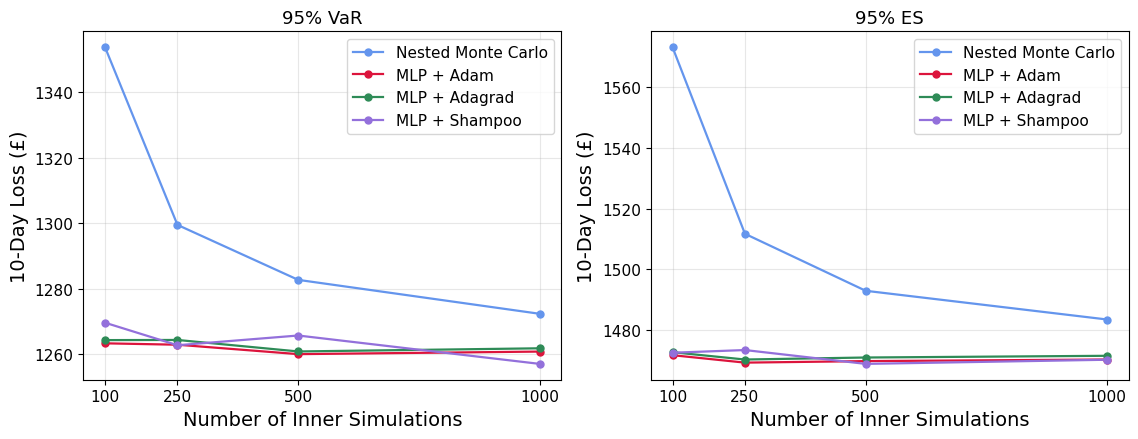

In [63]:
plot_risk_pair(
    confidence_level=95,
    filename="risk_measures_95"
)

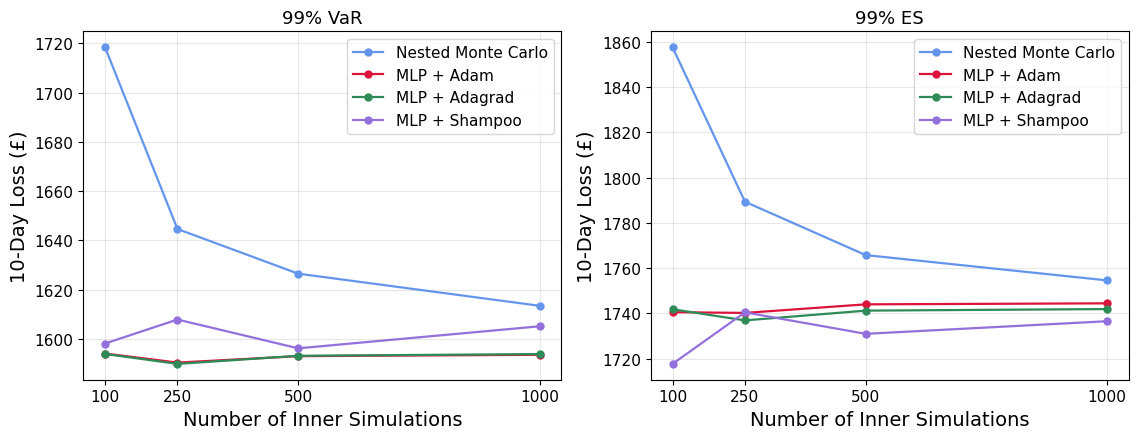

In [64]:
plot_risk_pair(
    confidence_level=99,
    filename="risk_measures_99"
)

In [32]:
# NMC Label Distribution Sensitivity

label_rows = []

for n_inner, dataset in sensitivity_datasets.items():

    cap_values = dataset[
        "Day 10 Cap Value (£)"
    ].to_numpy()

    label_rows.append({
        "Inner Paths": n_inner,
        "Mean V10 (£)": cap_values.mean(),
        "Std V10 (£)": cap_values.std(ddof=1),
        "5% V10 (£)": np.quantile(
            cap_values,
            0.05
        ),
        "1% V10 (£)": np.quantile(
            cap_values,
            0.01
        )
    })

label_distribution = pd.DataFrame(
    label_rows
)

label_distribution.style.format({
    "Mean V10 (£)": "£{:,.2f}",
    "Std V10 (£)": "£{:,.2f}",
    "5% V10 (£)": "£{:,.2f}",
    "1% V10 (£)": "£{:,.2f}"
})

,Inner Paths,Mean V10 (£),Std V10 (£),5% V10 (£),1% V10 (£)
0,1000,"£2,793.05",£928.11,"£1,506.05","£1,164.95"
1,500,"£2,793.74",£933.60,"£1,495.69","£1,151.92"
2,250,"£2,793.82",£944.90,"£1,478.90","£1,133.80"
3,100,"£2,793.95",£976.38,"£1,424.63","£1,060.04"


## Goodness of Fit Across Optimisers

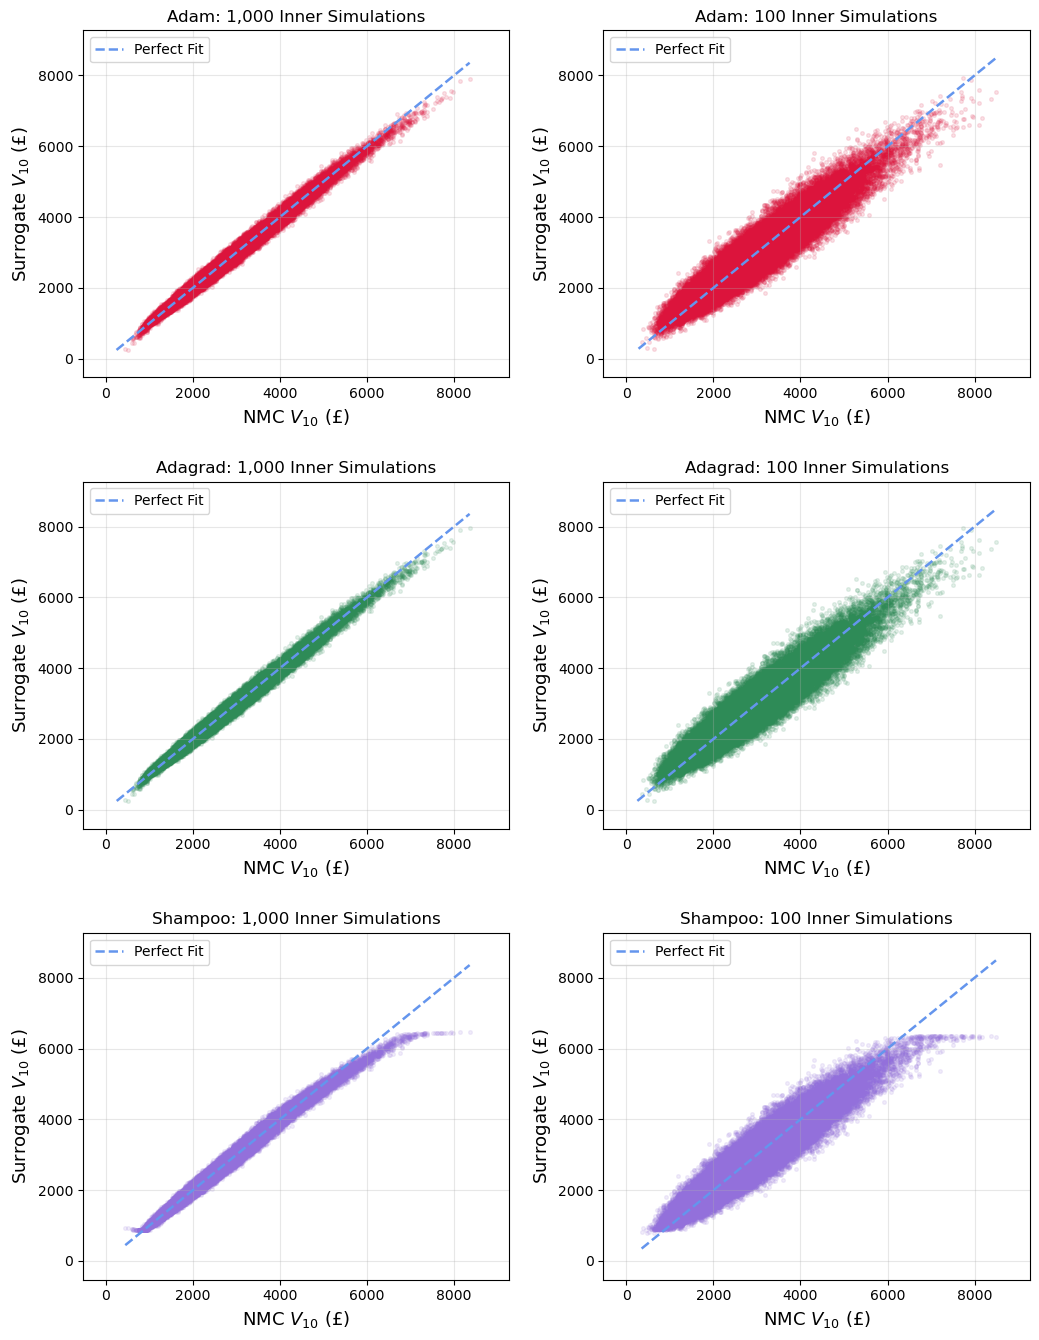

In [71]:
# ============================================================
# Figure 6: Goodness-of-Fit Plots
# ============================================================

optimiser_models = {
    "Adam": {
        1000: model_adam,
        100: sensitivity_models[100]["Adam"]
    },
    "Adagrad": {
        1000: model_adagrad,
        100: sensitivity_models[100]["Adagrad"]
    },
    "Shampoo": {
        1000: model_shampoo,
        100: sensitivity_models[100]["Shampoo"]
    }
}


fig, axes = plt.subplots(
    3,
    2,
    figsize=(10.5, 13.5)
)


for row, optimiser in enumerate(
    ["Adam", "Adagrad", "Shampoo"]
):

    for col, n_inner in enumerate(
        [1000, 100]
    ):

        ax = axes[row, col]

        dataset = sensitivity_datasets[
            n_inner
        ]

        data = prepared_data[
            n_inner
        ]

        model = optimiser_models[
            optimiser
        ][n_inner]


        # ====================================================
        # NMC V10 Values
        # ====================================================

        nmc_values = dataset[
            "Day 10 Cap Value (£)"
        ].to_numpy()


        # ====================================================
        # Prepare Full 100,000 Inputs
        # ====================================================

        rates = dataset[
            ["Day 10 Short Rate"]
        ].to_numpy(
            dtype=np.float32
        )

        X_tensor = torch.tensor(
            data["scaler_X"].transform(
                rates
            ),
            dtype=torch.float32
        )


        # ====================================================
        # Generate Surrogate V10 Values
        # ====================================================

        model.eval()

        with torch.no_grad():

            predictions_scaled = (
                model(X_tensor)
                .numpy()
            )

        surrogate_values = (
            data["scaler_y"]
            .inverse_transform(
                predictions_scaled
            )
            .flatten()
        )


        # ====================================================
        # Identity Line
        # ====================================================

        lower = min(
            nmc_values.min(),
            surrogate_values.min()
        )

        upper = max(
            nmc_values.max(),
            surrogate_values.max()
        )


        # ====================================================
        # Goodness-of-Fit Plot
        # ====================================================

        ax.scatter(
            nmc_values,
            surrogate_values,
            color=optimiser_colours[
                optimiser
            ],
            alpha=0.12,
            s=7,
            rasterized=True
        )

        ax.plot(
            [lower, upper],
            [lower, upper],
            color=nmc_colour,
            linestyle="--",
            linewidth=1.8,
            label="Perfect Fit"
        )

        ax.set_xlabel(
            r"NMC $V_{10}$ (£)",
            fontsize=13
        )

        ax.set_ylabel(
            r"Surrogate $V_{10}$ (£)",
            fontsize=13
        )

        ax.set_title(
            f"{optimiser}: "
            f"{n_inner:,} Inner Simulations",
            fontsize=12
        )

        ax.tick_params(
            axis="both",
            labelsize=10
        )

        ax.legend(
            fontsize=10
        )

        ax.grid(
            alpha=0.3
        )
        
        ax.legend(
            loc="upper left",
            fontsize=10
        )
# ============================================================
# Use Common Axis Limits Across All Panels
# ============================================================

all_limits = []

for ax in axes.flat:

    all_limits.extend(
        ax.get_xlim()
    )

    all_limits.extend(
        ax.get_ylim()
    )


global_lower = min(
    all_limits
)

global_upper = max(
    all_limits
)

padding = (
    0.02
    * (
        global_upper
        - global_lower
    )
)


for ax in axes.flat:

    ax.set_xlim(
        global_lower - padding,
        global_upper + padding
    )

    ax.set_ylim(
        global_lower - padding,
        global_upper + padding
    )

# ============================================================
# Use Common Axis Limits Across All Panels
# ============================================================

all_limits = []

for ax in axes.flat:

    all_limits.extend(
        ax.get_xlim()
    )

    all_limits.extend(
        ax.get_ylim()
    )


global_lower = min(
    all_limits
)

global_upper = max(
    all_limits
)

padding = (
    0.02
    * (
        global_upper
        - global_lower
    )
)


for ax in axes.flat:

    ax.set_xlim(
        global_lower - padding,
        global_upper + padding
    )

    ax.set_ylim(
        global_lower - padding,
        global_upper + padding
    )


plt.tight_layout(
    h_pad=2.5,
    w_pad=2.0
)

plt.subplots_adjust(
    hspace=0.30,
    wspace=0.22
)

plt.savefig(
    "figures/gof_normal.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Q-Q Plots: Surrogate vs NMC V10

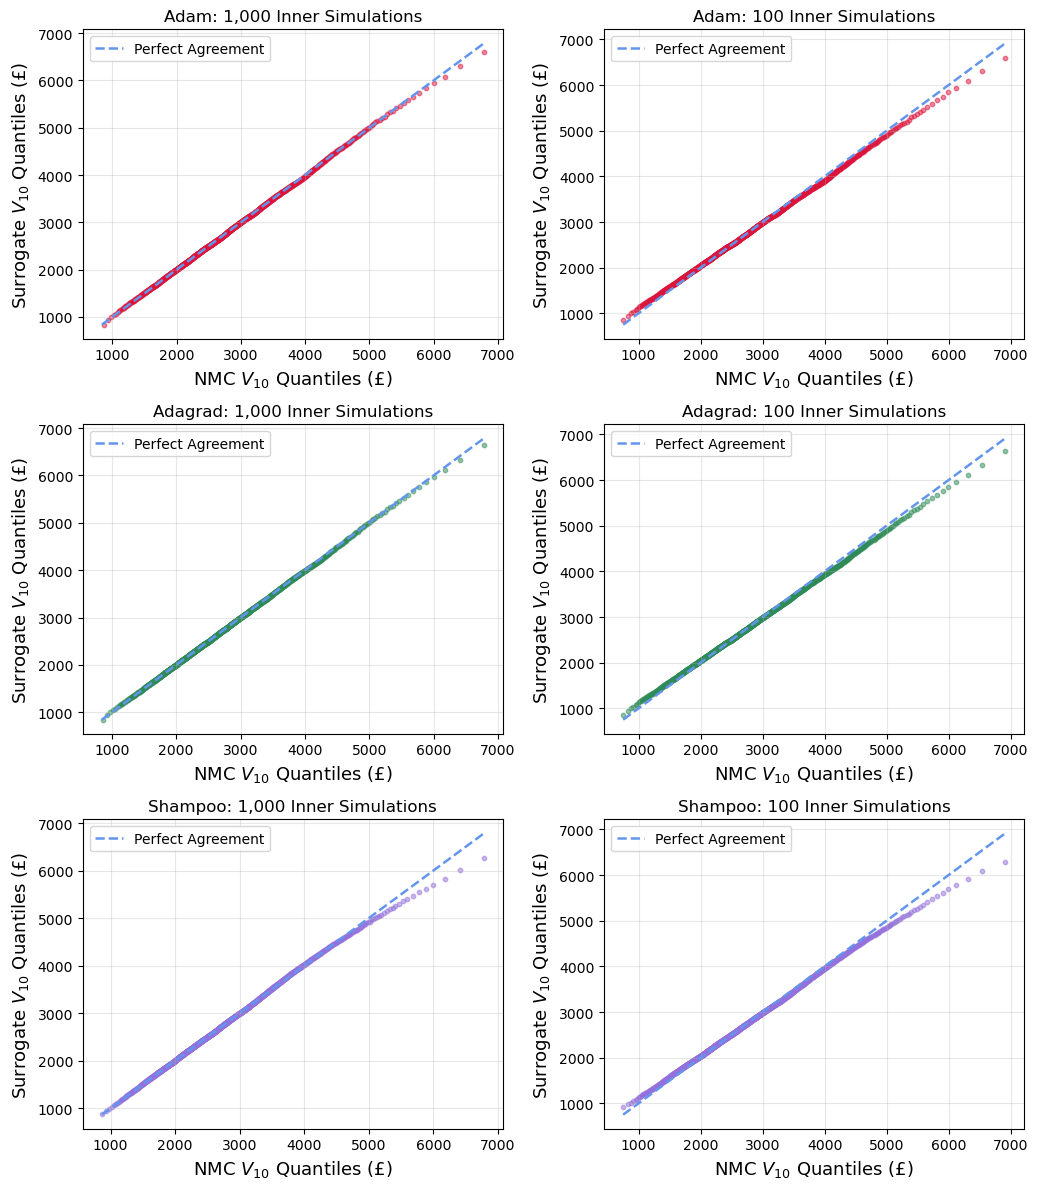

In [65]:
quantiles = np.linspace(
    0.001,
    0.999,
    1000
)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(10.5, 12)
)

for row, optimiser in enumerate(
    ["Adam", "Adagrad", "Shampoo"]
):

    for col, n_inner in enumerate(
        [1000, 100]
    ):

        ax = axes[row, col]

        dataset = sensitivity_datasets[
            n_inner
        ]

        data = prepared_data[
            n_inner
        ]

        model = optimiser_models[
            optimiser
        ][n_inner]


        # NMC V10 Values

        nmc_values = dataset[
            "Day 10 Cap Value (£)"
        ].to_numpy()


        # Prepare Inputs

        rates = dataset[
            ["Day 10 Short Rate"]
        ].to_numpy(
            dtype=np.float32
        )

        X_tensor = torch.tensor(
            data["scaler_X"].transform(
                rates
            ),
            dtype=torch.float32
        )


        # Surrogate V10 Values

        model.eval()

        with torch.no_grad():

            predictions_scaled = (
                model(X_tensor)
                .numpy()
            )

        surrogate_values = (
            data["scaler_y"]
            .inverse_transform(
                predictions_scaled
            )
            .flatten()
        )


        # Calculate Empirical Quantiles

        nmc_quantiles = np.quantile(
            nmc_values,
            quantiles
        )

        surrogate_quantiles = np.quantile(
            surrogate_values,
            quantiles
        )


        # Identity Line

        lower = min(
            nmc_quantiles.min(),
            surrogate_quantiles.min()
        )

        upper = max(
            nmc_quantiles.max(),
            surrogate_quantiles.max()
        )


        # Q-Q Plot

        ax.scatter(
            nmc_quantiles,
            surrogate_quantiles,
            color=optimiser_colours[
                optimiser
            ],
            alpha=0.5,
            s=10
        )

        ax.plot(
            [lower, upper],
            [lower, upper],
            color=nmc_colour,
            linestyle="--",
            linewidth=1.8,
            label="Perfect Agreement"
        )

        ax.set_xlabel(
            r"NMC $V_{10}$ Quantiles (£)",
            fontsize=13
        )

        ax.set_ylabel(
            r"Surrogate $V_{10}$ Quantiles (£)",
            fontsize=13
        )

        ax.set_title(
            f"{optimiser}: "
            f"{n_inner:,} Inner Simulations",
            fontsize=12
        )

        ax.tick_params(
            axis="both",
            labelsize=10
        )

        ax.legend(
            fontsize=10
        )

        ax.grid(
            alpha=0.3
        )


plt.tight_layout()

plt.savefig(
    "figures/gof_qq.pdf",
    bbox_inches="tight"
)

plt.show()

# 4. Cloudie

In [35]:
# Cloudie: 1,000 Inner Simulations

cloudie_1000 = create_cloudie_summary(
    metrics={
        "Adam": metrics_adam,
        "Adagrad": metrics_adagrad,
        "Shampoo": metrics_shampoo
    },
    losses={
        "Adam": losses_adam,
        "Adagrad": losses_adagrad,
        "Shampoo": losses_shampoo
    },
    risk_results=risk_sensitivity,
    n_inner=1000,
    tolerance=0.005
)

cloudie_1000.round(3)

,Optimiser,Predictive Accuracy Rank,Training Loss Rank,Risk-Measure Accuracy Rank,Cloudie Rank,Mean Risk-Measure Deviation (%),"Mean Risk-Measure Deviation from 1,000-inner NMC (%)"
0,Adagrad,1.333,1.0,1.5,1.278,0.893,0.893
1,Adam,1.667,2.0,2.0,1.889,0.902,0.902
2,Shampoo,3.000,3.0,2.5,2.833,0.910,0.910


# Cloudie Stress Test: 100 Inner Simulations Risk-Measure Accuracy

In [36]:
# Cloudie: 100 Inner Simulations

cloudie_100 = create_cloudie_summary(
    metrics=sensitivity_metrics[100],
    losses=sensitivity_losses[100],
    risk_results=risk_sensitivity,
    n_inner=100,
    tolerance=0.005
)

cloudie_100.round(3)

,Optimiser,Predictive Accuracy Rank,Training Loss Rank,Risk-Measure Accuracy Rank,Cloudie Rank,Mean Risk-Measure Deviation (%),"Mean Risk-Measure Deviation from 1,000-inner NMC (%)"
0,Adagrad,1.833,1.5,1.750,1.694,6.623,0.824
1,Adam,1.833,1.5,2.625,1.986,6.672,0.876
2,Shampoo,2.333,3.0,1.625,2.319,6.791,1.001


In [37]:
# Cloudie: 250 Inner Simulations

cloudie_250 = create_cloudie_summary(
    metrics=sensitivity_metrics[250],
    losses=sensitivity_losses[250],
    risk_results=risk_sensitivity,
    n_inner=250,
    tolerance=0.005
)

cloudie_250.round(3)

,Optimiser,Predictive Accuracy Rank,Training Loss Rank,Risk-Measure Accuracy Rank,Cloudie Rank,Mean Risk-Measure Deviation (%),"Mean Risk-Measure Deviation from 1,000-inner NMC (%)"
0,Adagrad,1.5,1.5,2.250,1.750,2.928,0.997
1,Adam,1.5,1.5,2.375,1.792,2.918,0.987
2,Shampoo,3.0,3.0,1.375,2.458,2.584,0.646


In [38]:
# Cloudie: 500 Inner Simulations

cloudie_500 = create_cloudie_summary(
    metrics=sensitivity_metrics[500],
    losses=sensitivity_losses[500],
    risk_results=risk_sensitivity,
    n_inner=500,
    tolerance=0.005
)

cloudie_500.round(3)

,Optimiser,Predictive Accuracy Rank,Training Loss Rank,Risk-Measure Accuracy Rank,Cloudie Rank,Mean Risk-Measure Deviation (%),"Mean Risk-Measure Deviation from 1,000-inner NMC (%)"
0,Adagrad,1.5,1.5,1.875,1.625,1.655,0.942
1,Adam,1.5,1.5,2.125,1.708,1.654,0.941
2,Shampoo,3.0,3.0,2.000,2.667,1.694,0.981


In [80]:
import shutil

shutil.make_archive(
    "dissertation_code",
    "zip",
    "NMC_Dissertationproject"
)

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'NMC_Dissertationproject'